# Notebook para fazer um stratified split dos dados

- A maior parte do código está comentado para não criar mais pastas ou adicionar mais imagens, visto que já está tudo criado

In [68]:
#Imports

import numpy as np
import keras
from keras.utils import image_dataset_from_directory
import matplotlib.pyplot as plt

import os
import shutil
from sklearn.model_selection import train_test_split

In [ ]:
#Ir buscar os paths de cada imagem

Image_paths =[]
for root, dirs, files in os.walk("wikiart_datasets"):
    for file in files:
        path = os.path.join(root,file)
        Image_paths.append(path)

    
    

In [ ]:
#Ir buscar os labels de cada imagem

labels= []
for root, dirs, files in os.walk("wikiart_datasets"):
    for file in files:
        labels.append(root[17:])

In [ ]:
#Dar split em train e test
X_train, X_test,  y_train, y_test = train_test_split(Image_paths,labels, test_size=0.3, train_size=0.7, stratify=labels)

In [ ]:
#Dar split do test e val e test
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, train_size=0.5, stratify=y_test)

In [ ]:
print(len(X_val),
      len(X_test),
      len(X_train))

# Cada split tem o tamanho que queremos

2001 2001 9338


In [ ]:
#Criar pasta data
#os.makedirs("/home/andre/Wikiart_Project/Data")

In [ ]:
#Criar pasta Train
#os.makedirs("/home/andre/Wikiart_Project/Data/Train")

In [ ]:
#Criar pasta Validation
#os.makedirs("/home/andre/Wikiart_Project/Data/Validation")

In [ ]:
#Criar pasta Test
#os.makedirs("/home/andre/Wikiart_Project/Data/Test")

In [ ]:
#Getting the unique labels
authors = set(labels)

In [ ]:
#Confirm if they are 23
len(authors)

23

In [ ]:
#Add the folders of the authors for Train
"""

for author in authors:
    if not os.path.exists(f"/home/andre/Wikiart_Project/Data/Train/{author}"):
        os.makedirs(f"/home/andre/Wikiart_Project/Data/Train/{author}")
    
"""

In [ ]:
#Add the folders of the authors for Test
"""

for author in authors:
    if not os.path.exists(f"/home/andre/Wikiart_Project/Data/Test/{author}"):
        os.makedirs(f"/home/andre/Wikiart_Project/Data/Test/{author}")

"""

In [ ]:
#Add the folders of the authors for Validation
"""
for author in authors:
    if not os.path.exists(f"/home/andre/Wikiart_Project/Data/Validation/{author}"):
        os.makedirs(f"/home/andre/Wikiart_Project/Data/Validation/{author}")

"""

In [ ]:
#Copiar os ficheiros para a pasta train
"""

for path in X_train:
    painter = path.split("/")[-2]
    shutil.copy(path, f"Data/Train/{painter}") 

"""

In [ ]:
#Copiar os ficheiros para a pasta test
"""

for path in X_test:
    painter = path.split("/")[-2]
    shutil.copy(path, f"Data/Test/{painter}") 

"""

In [ ]:
#Copiar os ficheiros para a pasta Validation
"""
for path in X_val:
    painter = path.split("/")[-2]
    shutil.copy(path, f"Data/Validation/{painter}") 

"""

## Test if the Stratified split was done write

### Train Data set

In [64]:
Train_df = image_dataset_from_directory(
    "Data/Train",
    label_mode= "categorical",
    batch_size= 64,
    image_size= (512,512),
    interpolation= "bilinear",
    verbose= False
)

I0000 00:00:1776274095.849904  115747 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5146 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a


In [65]:
authors_painting_filepaths = {}

for c in Train_df.class_names:
    class_path = f"Data/Train/{c}"
    authors_painting_filepaths[c] = [os.path.join(class_path, f) for f in os.listdir(class_path)]

In [67]:
count = {c: len(paths) for c, paths in authors_painting_filepaths.items()}

for class_name, number in count.items():
    print(f"Author {class_name} has {number} paintings")

Author Albrecht_Durer has 406 paintings
Author Boris_Kustodiev has 311 paintings
Author Camille_Pissarro has 435 paintings
Author Childe_Hassam has 269 paintings
Author Claude_Monet has 654 paintings
Author Edgar_Degas has 300 paintings
Author Eugene_Boudin has 272 paintings
Author Gustave_Dore has 370 paintings
Author Ilya_Repin has 265 paintings
Author Ivan_Aivazovsky has 283 paintings
Author Ivan_Shishkin has 255 paintings
Author John_Singer_Sargent has 384 paintings
Author Marc_Chagall has 375 paintings
Author Martiros_Saryan has 282 paintings
Author Nicholas_Roerich has 892 paintings
Author Pablo_Picasso has 374 paintings
Author Paul_Cezanne has 284 paintings
Author Pierre_Auguste_Renoir has 682 paintings
Author Pyotr_Konchalovsky has 451 paintings
Author Raphael_Kirchner has 253 paintings
Author Rembrandt has 381 paintings
Author Salvador_Dali has 235 paintings
Author Vincent_van_Gogh has 925 paintings


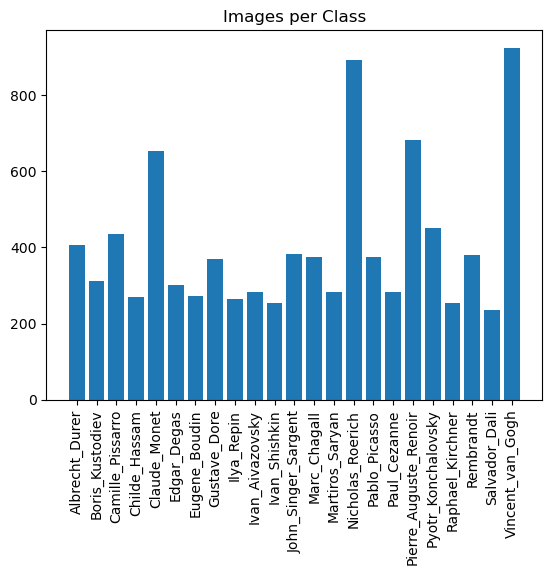

In [69]:
plt.bar(count.keys(), count.values())
plt.xticks(rotation=90)
plt.title("Images per Class")
plt.show()

### Validation Data set

In [70]:
Val_df = image_dataset_from_directory(
    "Data/Validation",
    label_mode= "categorical",
    batch_size= 64,
    image_size= (512,512),
    interpolation= "bilinear",
    verbose= False
)

In [71]:
authors_painting_filepaths = {}

for c in Val_df.class_names:
    class_path = f"Data/Validation/{c}"
    authors_painting_filepaths[c] = [os.path.join(class_path, f) for f in os.listdir(class_path)]

In [73]:
count = {c: len(paths) for c, paths in authors_painting_filepaths.items()}

for class_name, number in count.items():
    print(f"Author {class_name} has {number} paintings")

Author Albrecht_Durer has 87 paintings
Author Boris_Kustodiev has 67 paintings
Author Camille_Pissarro has 93 paintings
Author Childe_Hassam has 58 paintings
Author Claude_Monet has 140 paintings
Author Edgar_Degas has 64 paintings
Author Eugene_Boudin has 59 paintings
Author Gustave_Dore has 79 paintings
Author Ilya_Repin has 56 paintings
Author Ivan_Aivazovsky has 61 paintings
Author Ivan_Shishkin has 54 paintings
Author John_Singer_Sargent has 82 paintings
Author Marc_Chagall has 80 paintings
Author Martiros_Saryan has 61 paintings
Author Nicholas_Roerich has 191 paintings
Author Pablo_Picasso has 80 paintings
Author Paul_Cezanne has 61 paintings
Author Pierre_Auguste_Renoir has 147 paintings
Author Pyotr_Konchalovsky has 97 paintings
Author Raphael_Kirchner has 54 paintings
Author Rembrandt has 81 paintings
Author Salvador_Dali has 50 paintings
Author Vincent_van_Gogh has 199 paintings


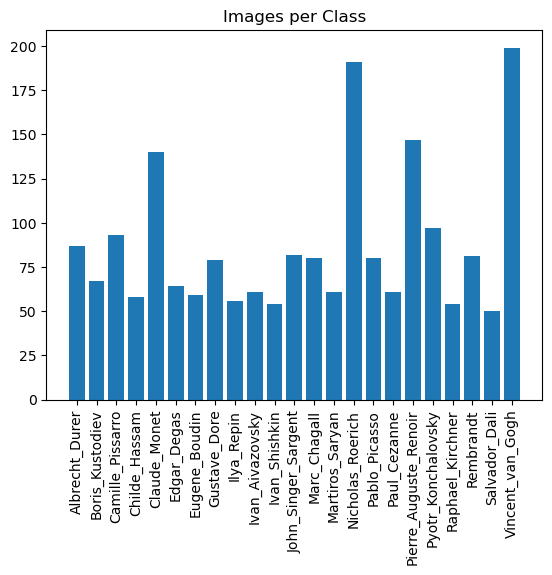

In [74]:
plt.bar(count.keys(), count.values())
plt.xticks(rotation=90)
plt.title("Images per Class")
plt.show()

### Test Data Set

In [75]:
Test_df = image_dataset_from_directory(
    "Data/Test",
    label_mode= "categorical",
    batch_size= 64,
    image_size= (512,512),
    interpolation= "bilinear",
    verbose= False)

In [76]:
authors_painting_filepaths = {}

for c in Test_df.class_names:
    class_path = f"Data/Test/{c}"
    authors_painting_filepaths[c] = [os.path.join(class_path, f) for f in os.listdir(class_path)]

In [77]:
count = {c: len(paths) for c, paths in authors_painting_filepaths.items()}

for class_name, number in count.items():
    print(f"Author {class_name} has {number} paintings")

Author Albrecht_Durer has 87 paintings
Author Boris_Kustodiev has 66 paintings
Author Camille_Pissarro has 93 paintings
Author Childe_Hassam has 58 paintings
Author Claude_Monet has 140 paintings
Author Edgar_Degas has 64 paintings
Author Eugene_Boudin has 58 paintings
Author Gustave_Dore has 79 paintings
Author Ilya_Repin has 57 paintings
Author Ivan_Aivazovsky has 60 paintings
Author Ivan_Shishkin has 55 paintings
Author John_Singer_Sargent has 83 paintings
Author Marc_Chagall has 81 paintings
Author Martiros_Saryan has 60 paintings
Author Nicholas_Roerich has 191 paintings
Author Pablo_Picasso has 80 paintings
Author Paul_Cezanne has 61 paintings
Author Pierre_Auguste_Renoir has 146 paintings
Author Pyotr_Konchalovsky has 96 paintings
Author Raphael_Kirchner has 55 paintings
Author Rembrandt has 82 paintings
Author Salvador_Dali has 51 paintings
Author Vincent_van_Gogh has 198 paintings


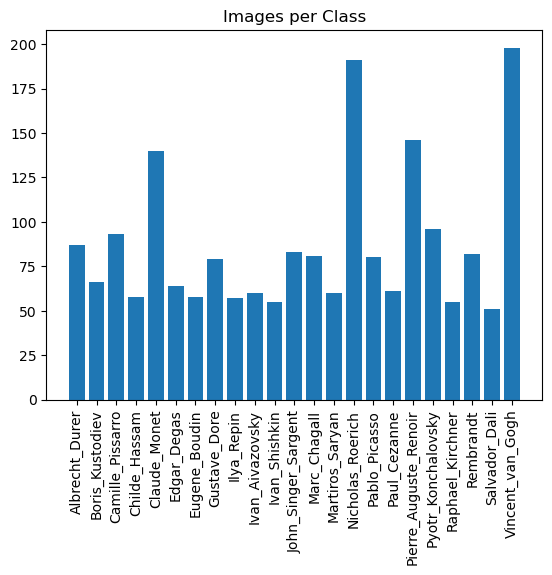

In [78]:
plt.bar(count.keys(), count.values())
plt.xticks(rotation=90)
plt.title("Images per Class")
plt.show()

As we can see in the 3 Graphs plotted above, they are equal so the distribution of classes in the 3 datasets is the same, therefore we can conclude that the stratified sampling splits was well done.